### 2048

In [9]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

import random

env = gym.make("gymnasium_2048:gymnasium_2048/TwentyFortyEight-v0", size=4, max_pow=16, render_mode = "rgb_array")

In [10]:
#Variables
gamma = 0.99
alpha = 0.1

#brain
global w 
w = np.random.uniform(-1, 1, size=64*16)
w_ = w.copy()

In [11]:
def render_board(env):

    frame = env.render()

    plt.figure(figsize=(5, 5))
    plt.imshow(frame)
    plt.axis('off')  
    plt.show()

In [12]:
def x(env, a):

    raw_grid = env.unwrapped.board

    ret = np.full((64*16), -0.01)

    for i in range(0,4):
        for j in range(0, 4):
            if(raw_grid[i][j] != 0):
                val = int(raw_grid[i][j])
                ret[a*16 + 4*i + j + 64*(val - 1)] = 1

    return ret
        

In [13]:
def q(env, a):

    return np.transpose(w) @ x(env, a)

In [14]:
def A(env):

    Q = np.zeros((env.action_space.n))
    for i in range(0, 4):
        Q[i] = q(env, i)
    return np.argmax(Q)

In [15]:
def update_live_plot(history):
    if len(history) == 1:
        plt.ion()
        plt.figure(figsize=(8, 4))
    
    plt.clf()
    
    plt.plot(history, alpha=0.3, color='blue', label='Raw Score')
    
    if len(history) >= 50:
        moving_avg = np.convolve(history, np.ones(50)/50, mode='valid')
        plt.plot(range(49, len(history)), moving_avg, color='red', linewidth=2, label='50-Ep Rolling Avg')
    
    plt.title(f'Training Progress (Episode {len(history)})')
    plt.xlabel('Episodes')
    plt.ylabel('Total Score')
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.pause(0.001)

In [16]:
def sara(env, episodes):
    global w
    history = []
    for i in range(episodes):
        obs, info = env.reset()
        a = A(env) 
        j = 0
        episode_reward = 0
        while(True):
            x_ =  x(env, a)
            q_ = q(env, a)
            next_state_, reward_, terminated_, truncated_, info_ = env.step(a) 
            episode_reward += reward_
            
            if reward_ == 0:
                j += 1
            else:
                j = 0
            if(j > 2):
                next_state_, reward_, terminated_, truncated_, info_ = env.step(random.randint(0,3)) 
                episode_reward += reward_
                j = 0
                
            if terminated_ or truncated_:
                w += alpha * (reward_ - q_) * x_
                break
            
            max_q_next = max([q(env, b) for b in range(4)])
            w += alpha * (reward_ + gamma * max_q_next - q_) * x_
            
            obs = next_state_
            a = A(env)
            
        history.append(episode_reward)
            
    update_live_plot(history)
    render_board(env)

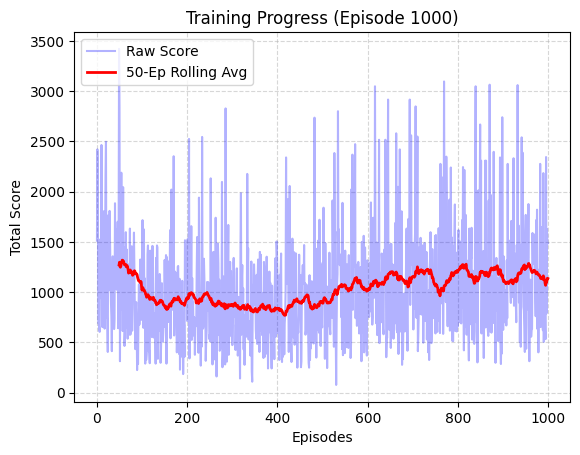

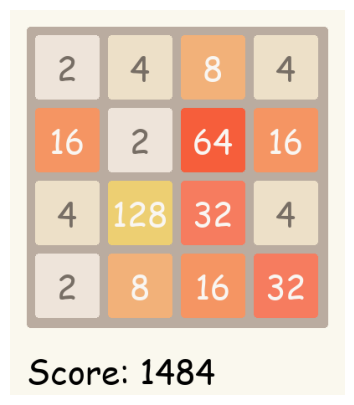

In [17]:
env.reset()
#print(alpha)
sara(env, episodes=1000)
#print(w)
#print(w - w_)
#print(env.unwrapped.board)